# Exercise 4: Blockchain Scalability, the Trilemma & Layer-2 Solutions

**COMP842 Applied Blockchains and Cryptocurrencies**

- Name: Sokhour Lay
- Student ID: 25314544

### 1. Given parameters and the TPS formula

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Parameters given in the assignment brief
BYTES_PER_MB   = 1_000_000   # 1 MB is treated as 1,000,000 bytes (decimal)
AVG_TX_BYTES   = 580         # average transaction size
BLOCK_TIME_SEC = 576         # average block time

def tps(block_size_mb, avg_tx_bytes=AVG_TX_BYTES, block_time_sec=BLOCK_TIME_SEC):
    """Return (block bytes, transactions per block, transactions per second)."""
    block_bytes  = block_size_mb * BYTES_PER_MB
    tx_per_block = block_bytes / avg_tx_bytes
    return block_bytes, tx_per_block, tx_per_block / block_time_sec

print("Given parameters")
print(f"  Block size      : 1 MB ({BYTES_PER_MB:,} bytes)")
print(f"  Avg transaction : {AVG_TX_BYTES} bytes")
print(f"  Avg block time  : {BLOCK_TIME_SEC} seconds")
print()
print("Formula: TPS = (block size in bytes / average transaction size) / block time")

Given parameters
  Block size      : 1 MB (1,000,000 bytes)
  Avg transaction : 580 bytes
  Avg block time  : 576 seconds

Formula: TPS = (block size in bytes / average transaction size) / block time


**Explanation:** the parameters from the assignment brief are defined first, and
`tps()` applies the throughput formula. One megabyte is taken as 1,000,000 bytes
(decimal), and this convention is used consistently throughout the exercise.

### 2. Calculating the theoretical TPS at 1 MB, 2 MB and 4 MB

In [2]:
for mb in (1, 2, 4):
    block_bytes, tx_per_block, throughput = tps(mb)
    print(f"Block size = {mb} MB")
    print(f"  Step 1  transactions per block = {block_bytes:,} / {AVG_TX_BYTES}"
          f" = {tx_per_block:,.2f}")
    print(f"  Step 2  TPS = {tx_per_block:,.2f} / {BLOCK_TIME_SEC}"
          f" = {throughput:.2f} TPS")
    print()

Block size = 1 MB
  Step 1  transactions per block = 1,000,000 / 580 = 1,724.14
  Step 2  TPS = 1,724.14 / 576 = 2.99 TPS

Block size = 2 MB
  Step 1  transactions per block = 2,000,000 / 580 = 3,448.28
  Step 2  TPS = 3,448.28 / 576 = 5.99 TPS

Block size = 4 MB
  Step 1  transactions per block = 4,000,000 / 580 = 6,896.55
  Step 2  TPS = 6,896.55 / 576 = 11.97 TPS



**Explanation:** each calculation is shown in two steps. Step 1 divides the block
size by the average transaction size to find how many transactions fit in one
block, and Step 2 divides that by the block time to give transactions per second.
The block time stays at 576 seconds in all three cases, so only the block size
changes.

### 3. Results table

In [3]:
rows = []
baseline = tps(1)[2]

for mb in (1, 2, 4):
    block_bytes, tx_per_block, throughput = tps(mb)
    rows.append({
        "Block size (MB)":        mb,
        "Block size (bytes)":     f"{block_bytes:,}",
        "Transactions per block": round(tx_per_block, 2),
        "TPS":                    round(throughput, 2),
        "Increase vs 1 MB":       f"{throughput / baseline:.1f}x",
    })

results = pd.DataFrame(rows)
results

,Block size (MB),Block size (bytes),Transactions per block,TPS,Increase vs 1 MB
0,1,"1,000,000",1724.14,2.99,1.0x
1,2,"2,000,000",3448.28,5.99,2.0x
2,4,"4,000,000",6896.55,11.97,4.0x


**Explanation:** the three results are placed side by side. The throughput rises
from 2.99 TPS at 1 MB to 5.99 TPS at 2 MB and 11.97 TPS at 4 MB. Doubling the
block size doubles the throughput, so the relationship is linear.

### 4. Throughput versus block size

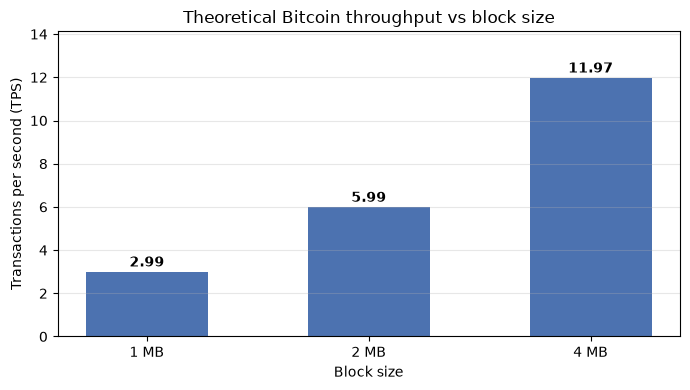

In [4]:
sizes  = [1, 2, 4]
values = [tps(mb)[2] for mb in sizes]

plt.figure(figsize=(7, 4))
bars = plt.bar([f"{s} MB" for s in sizes], values, color="#4C72B0", width=0.55)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.25,
             f"{value:.2f}", ha="center", fontweight="bold")

plt.title("Theoretical Bitcoin throughput vs block size")
plt.xlabel("Block size")
plt.ylabel("Transactions per second (TPS)")
plt.ylim(0, max(values) * 1.18)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Explanation:** the chart shows the throughput at each block size. The bars rise
in equal steps, which confirms that the growth is linear: each extra megabyte adds
about the same amount of throughput, unlike the exponential growth of mining
effort seen in Exercise 2.

### 5. Comparison with a traditional payment system (Visa)

In [5]:
bitcoin_tps = tps(1)[2]
visa_tps    = 24_000        # figure used in the Week 5 lecture

comparison = pd.DataFrame({
    "Characteristic": [
        "Throughput (TPS)",
        "Time to confirm a transaction",
        "Architecture",
        "Who validates transactions",
        "Main scalability bottleneck",
        "How it scales",
    ],
    "Bitcoin (1 MB block)": [
        f"{bitcoin_tps:.2f}",
        "About 576 seconds per block",
        "Decentralised peer-to-peer network",
        "Thousands of independent full nodes",
        "Fixed block size and fixed block time",
        "Protocol changes (Layer 1) or off-chain channels (Layer 2)",
    ],
    "Visa": [
        f"{visa_tps:,}",
        "A few seconds",
        "Centralised network",
        "A single trusted operator",
        "Data-centre capacity",
        "Add more servers and data-centre capacity",
    ],
})

print(f"Visa handles about {visa_tps / bitcoin_tps:,.0f} times Bitcoin's "
      f"theoretical throughput.\n")
comparison

Visa handles about 8,018 times Bitcoin's theoretical throughput.



,Characteristic,Bitcoin (1 MB block),Visa
0,Throughput (TPS),2.99,"24,000"
1,Time to confirm a transaction,About 576 seconds per block,A few seconds
2,Architecture,Decentralised peer-to-peer network,Centralised network
3,Who validates transactions,Thousands of independent full nodes,A single trusted operator
4,Main scalability bottleneck,Fixed block size and fixed block time,Data-centre capacity
5,How it scales,Protocol changes (Layer 1) or off-chain channe...,Add more servers and data-centre capacity


**Explanation:** Visa processes roughly 24,000 transactions per second, about
8,000 times Bitcoin's theoretical 2.99 TPS. The difference is not only a matter of
capacity but of design: Visa is a centralised system operated by one trusted
company and scales by adding hardware, while Bitcoin is validated independently by
thousands of nodes and is limited by its fixed block size and block time.

### 6. Two scalability solutions

The Week 5 lecture divides scalability solutions into Layer 1 solutions, which are protocol-level changes made directly to the blockchain, and Layer 2 solutions, which operate on top of the base blockchain while still relying on it for final security and settlement. One solution of each type was selected: Segregated Witness as a Layer 1 solution and the Lightning Network as a Layer 2 solution. Both were chosen because they apply directly to Bitcoin, which is the blockchain used in the calculations above.

#### 6.1 Segregated Witness (SegWit) — a Layer 1 solution

Segregated Witness is a Layer 1 solution, meaning it changes the Bitcoin protocol itself. Every Bitcoin transaction contains two kinds of data: the transaction details, such as the inputs and outputs, and the witness data, which is the digital signature that proves the sender owns the coins. SegWit separates the witness data from the transaction data so that signatures are no longer counted in the same way towards the block limit (Lombrozo et al., 2015).

To do this, SegWit replaces the old one megabyte block size rule with a new measure called block weight, where block weight is calculated as the base size multiplied by three plus the total size, and a block must not exceed 4,000,000 weight units (Lombrozo et al., 2015). Because witness data is only counted once while the rest of the transaction is counted four times, signature data effectively takes up a quarter of the space it used to. More transactions therefore fit into each block without the one megabyte limit on transaction data being raised directly, which increases throughput. In practice this gives an effective capacity of roughly two megabytes of transaction data per block, depending on the mix of transactions, which corresponds to about 5.99 transactions per second in the calculations in Section 2.

SegWit also produced an important side effect. Because the signature is no longer part of the data used to calculate the transaction identifier, the identifier can no longer be changed by altering the signature, so unintentional transaction malleability becomes impossible (Lombrozo et al., 2015). This mattered beyond scalability, because reliable transaction identifiers are required for payment channels, which made the Lightning Network practical.

#### 6.2 The Lightning Network — a Layer 2 solution

The Lightning Network is a Layer 2 solution, which means it runs on top of Bitcoin and uses the main chain only for final security and settlement. Instead of recording every payment on the blockchain, two users open a payment channel by locking funds in a shared two-of-two multi-signature address, which requires signatures from both parties before the money can be moved (Poon & Dryja, 2016). Once the channel is open, the two parties can pay each other many times by exchanging updated balances directly between themselves, and none of these payments touch the blockchain. Only when the channel is closed is the final balance written to the main chain.

Poon and Dryja (2016) argue that if only two participants care about an everyday recurring transaction, it is not necessary for every other node in the Bitcoin network to know about that transaction. This is the key to the scalability gain: a channel that carries a thousand payments still costs only two on-chain transactions, one to open it and one to close it, so the load on the blockchain no longer grows with the number of payments. Payments can also be routed through several connected channels using Hashed Timelock Contracts, which use time locks so that funds are returned if one party stops responding, allowing users to pay people they have no direct channel with (Poon & Dryja, 2016).

#### 6.3 Comparing the two approaches

The two solutions attack the problem from different directions. SegWit increases how much fits inside each block, so it improves throughput but remains bounded by the block size and block time, exactly as the calculations in Section 2 show. Even at four megabytes the theoretical throughput reaches only about 11.97 transactions per second, which is still far below the roughly 24,000 transactions per second of Visa. The Lightning Network instead removes most payments from the blockchain altogether, so its capacity is not limited by block size at all. A Layer 1 change alone cannot close a gap of around 8,000 times, which is why Layer 2 solutions are considered necessary for Bitcoin to handle payment-scale volumes.

The main advantage is a direct increase in transaction throughput. Doubling the block size doubles the number of transactions that fit into each block while the block time stays the same, so the theoretical throughput calculated in Section 2 rises from 2.99 to 5.99 transactions per second. This allows more transactions to be confirmed in the same period, which reduces congestion and the high fees that occur when demand for block space is greater than the space available.

The main disadvantage is that every full node must download, transmit, and store twice as much data. This raises the cost of running a full node, and if fewer participants can afford to run one, validation concentrates among fewer operators and the network becomes less decentralised. Larger blocks also propagate more slowly across the network, which increases the stale block rate and can weaken security (Gervais, 2016). The same study notes, however, that increasing the block size up to 4 MB does not significantly reduce resistance to double spending provided the propagation mechanism keeps the stale block rate low, so the severity of this effect depends on how efficiently blocks are distributed. Increasing the block size therefore buys scalability at the expense of decentralisation, which is the central trade-off described by the Blockchain Trilemma.